# Análise Estatíticas Descritvas por Fator

## Importação das Bibliotecas

In [4]:
import sys
from pathlib import Path
import warnings
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# 1. Configurações gerais
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# 2. Ativação do autoreload via API do IPython (compatível e sem SyntaxError no VS Code)
try:
    get_ipython().run_line_magic('load_ext', 'autoreload')
    get_ipython().run_line_magic('autoreload', '2')
except NameError:
    pass

# 3. Adiciona a pasta scripts ao caminho do Python ANTES de importar os módulos locais
sys.path.append(str(Path.cwd().parent / 'scripts'))

# 4. Importação dos módulos do seu projeto
from prepara_dados_fator import prepara_dados_fator
from executa_teste_quiquadrado import executa_teste_quiquadrado
from verifica_pressupostos_anova import verifica_pressupostos_anova
from executa_anova_oneway import executa_anova_oneway
from executa_kruskal_wallis import executa_kruskal_wallis
from executa_tukey_hsd import executa_tukey_hsd
from executa_posthoc_mannwhitney import executa_posthoc_mannwhitney
from plota_boxplot_fator import plota_boxplot_fator
from plota_barras_ponderadas import plota_barras_ponderadas
from formata_tabela import formata_tabela


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Leitura do arquivo de dados

In [2]:
df = pd.read_parquet('../Data/Candidatos_Tratados.parquet')

## Análise Estatística Descritiva por Fator

As seguintes etapas serão seguidas para todos os fatores analisados:

1. Preparação da base de dados e geração da tabela estatística descritiva

Nesta etapa, é realizado o agrupamento da taxa de conclusão real de cada Instituto Federal (nível institucional). Os resultados são organizados em uma tabela comparando as medidas descritivas (mínimo, mediana, média simples e desvio-padrão dos IFs) com a Taxa Ponderada Global dos alunos na Rede Federal.

2. Teste Qui-Quadrado de Independência (Nível Discente)

Neste teste, cada estudante possui o mesmo peso na análise, independentemente de a sua instituição de origem ter 500 ou 50 mil alunos. O objetivo é responder se a probabilidade de conclusão ou evasão do aluno está estatisticamente associada ao fator sociodemográfico avaliado.

3. Teste de normalidade

Ao se aplicar a ANOVA deve-se verificar se pressupostos de Gauss-Markov (normalidade dos resíduos via Shapiro-Wilk e homogeneidade das variâncias via Levene) são atendidos. 

Neste estudo, constatou-se que apenas a variável Região satisfez ambos os pressupostos, autorizando o uso da ANOVA paramétrica de Fisher e do teste post-hoc de Tukey HSD. Para as variáveis Etnia, Renda, Faixa Etária e Sexo, em virtude da violação da normalidade, adotou-se o teste não-paramétrico de Kruskal-Wallis (ANOVA por postos), assegurando a robustez inferencial das conclusões.

4. Análise de Variância (ANOVA One-Way) ou Teste de Kruskal-Wallis (Nível Institucional)

A escolha entre o método paramétrico ou não-paramétrico depende da verificação formal dos pressupostos da ANOVA (normalidade dos resíduos via Shapiro-Wilk e homocedasticidade via Levene). Caso ambos os pressupostos sejam atendidos, aplica-se a ANOVA de Fisher; caso algum ou ambos sejam violados, aplica-se o Teste de Kruskal-Wallis (ANOVA por postos). Ambos os testes avaliam se a influência do fator sobre as taxas institucionais é estatisticamente significante. A diferença fundamental em relação ao Qui-Quadrado é a base de observação: enquanto no Qui-Quadrado a unidade é o estudante, na ANOVA e no Kruskal-Wallis a unidade é a taxa de cada Instituto Federal, tendo cada instituição o mesmo peso independente do número de estudantes matriculados.

4. Comparações Múltiplas Par a Par (Pós-teste)

Quando o teste global indicar diferença estatisticamente significante ($p < 0,05$), realiza-se o teste par a par para identificar quais categorias diferem entre si: via Tukey HSD (se o modelo for a ANOVA paramétrica) ou via Teste de Mann-Whitney com correção de Bonferroni (se o modelo for o Kruskal-Wallis não-paramétrico).

5. Visualização Gráfica (Boxplot com Strip Plot)

Elaboração de gráfico boxplot para visualização da dispersão das taxas das instituições, destacando as medianas, a média de cada grupo, cada IF individualizado e a linha de referência da média nacional.


    

ANÁLISE ESTATÍSTICA DESCRITIVA PARA O REG


REG             N_IFS  MEDIA  DESVIO_PADRAO  MEDIANA    MIN    MAX  TAXA_PONDERADA
----------------------------------------------------------------------------------
Sul                 6  59.98          17.37    53.95  41.74  81.57           78.52
Sudeste             9  59.79          14.52    53.69  43.96  80.42           63.44
Norte               7  48.88           5.38    45.73  44.18  57.36           48.95
Centro-Oeste        5  47.23          14.06    45.04  35.05  69.87           41.97
Nordeste           11  42.38           7.38    42.47  30.29  56.39           43.64


A conclusão do aluno é DEPENDENTE de REG (p < 0.05).




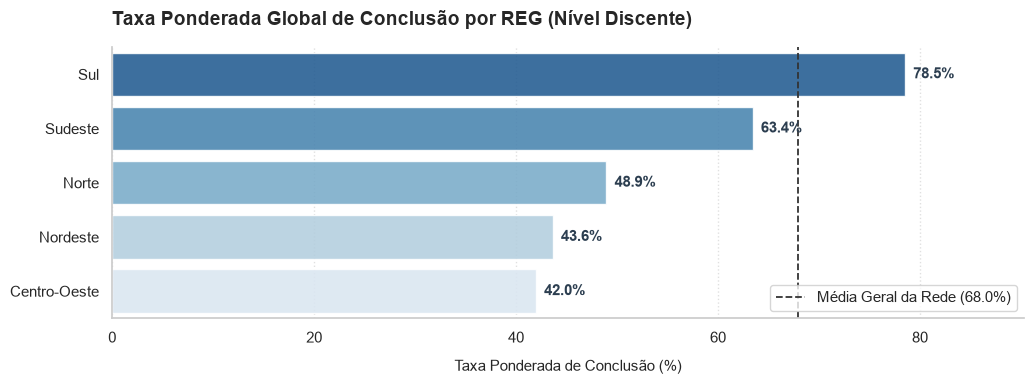

ANOVA One-Way: F = 3.6793 | p-valor = 1.3863e-02


Comparação                  Diferença das Médias (%)  p-valor   Significante?
-----------------------------------------------------------------------------
Centro-Oeste vs Nordeste                        4.85     0.94             Não
Centro-Oeste vs Norte                          -1.65     1.00             Não
Centro-Oeste vs Sudeste                       -12.56     0.34             Não
Centro-Oeste vs Sul                           -12.75     0.41             Não
Nordeste vs Norte                              -6.50     0.79             Não
Nordeste vs Sudeste                           -17.41     0.02  Sim (p < 0.05)
Nordeste vs Sul                               -17.60     0.05  Sim (p < 0.05)
Norte vs Sudeste                              -10.91     0.38             Não
Norte vs Sul                                  -11.10     0.47             Não
Sudeste vs Sul                                 -0.19     1.00             Não




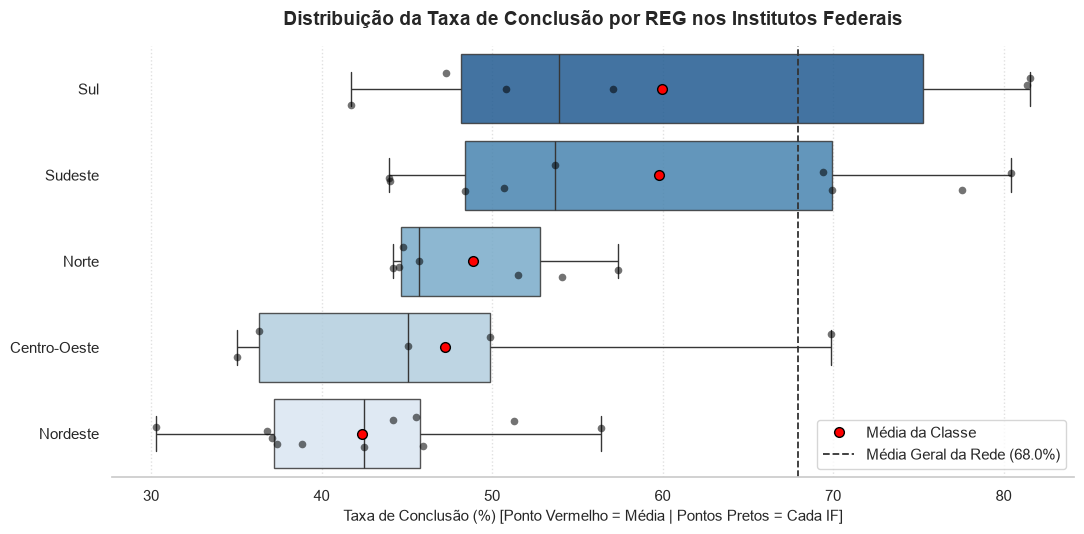



ANÁLISE ESTATÍSTICA DESCRITIVA PARA O ETNIA


ETNIA       N_IFS  MEDIA  DESVIO_PADRAO  MEDIANA    MIN     MAX  TAXA_PONDERADA
-------------------------------------------------------------------------------
Amarela        38  56.55          17.45    51.31  35.18  105.29           73.02
Branca         38  52.67          13.79    49.50  28.26   81.95           70.45
Parda          38  50.20          14.03    46.03  31.20   87.84           66.02
Indígena       38  48.70          19.21    46.59  27.64   93.55           63.09
Preta          38  47.97          14.38    44.05  27.88   81.73           65.32


A conclusão do aluno é DEPENDENTE de ETNIA (p < 0.05).




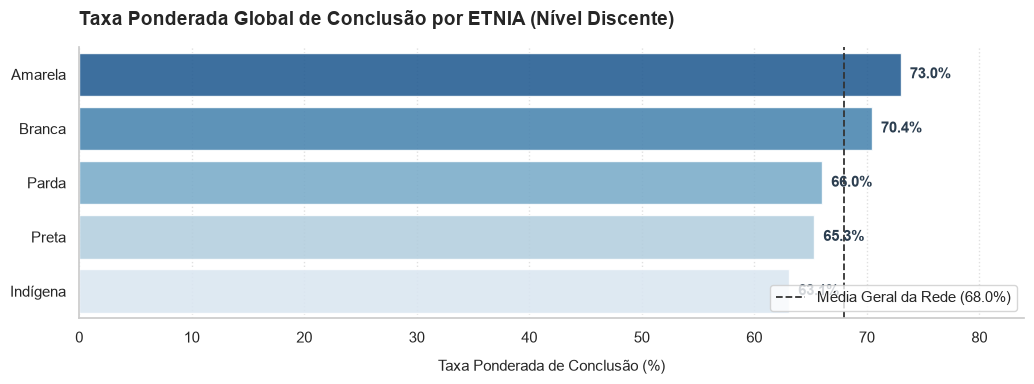

Kruskal-Wallis: H = 9.5049 | p-valor = 4.9647e-02
Comparação             Dif. Medianas (%)  Estatística U  p-valor Bruto  p-valor Ajustado  Significante?
-------------------------------------------------------------------------------------------------------
Amarela vs Branca                   1.81         808.00           0.37              1.00            Não
Amarela vs Indígena                 4.72         942.00           0.02              0.23            Não
Amarela vs Parda                    5.28         907.00           0.06              0.55            Não
Amarela vs Preta                    7.26         954.50           0.02              0.16            Não
Branca vs Indígena                  2.91         861.00           0.15              1.00            Não
Branca vs Parda                     3.47         828.00           0.27              1.00            Não
Branca vs Preta                     5.45         896.00           0.07              0.71            Não
Indígena vs Pa

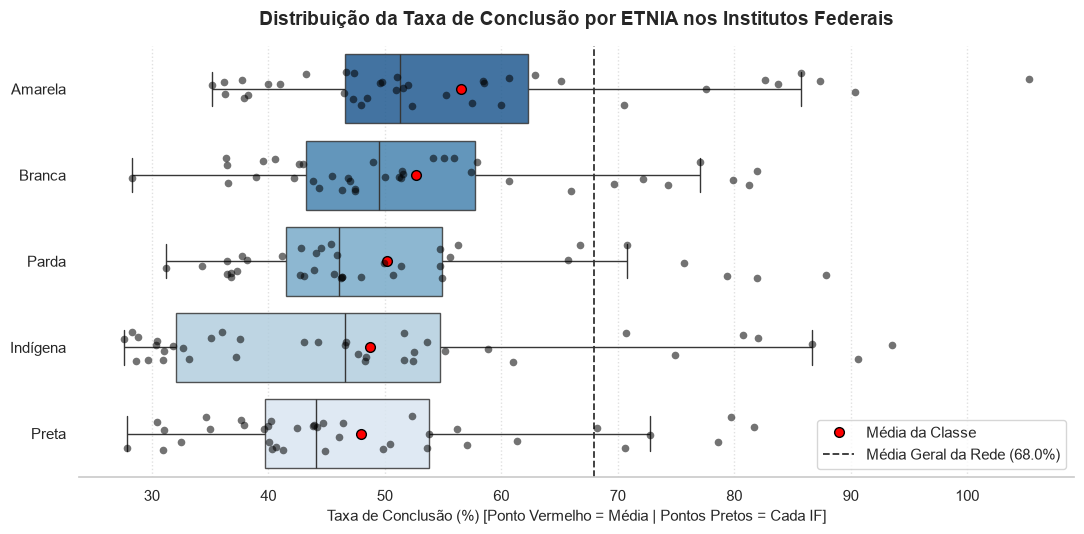



ANÁLISE ESTATÍSTICA DESCRITIVA PARA O FAIXA_ETARIA


FAIXA_ETARIA    N_IFS  MEDIA  DESVIO_PADRAO  MEDIANA    MIN     MAX  TAXA_PONDERADA
-----------------------------------------------------------------------------------
20 a 24            38  67.77          20.16    64.54  35.46  119.33           73.47
> 60               38  64.38          19.08    63.71  28.57  100.00           82.09
55 a 59            38  61.68          16.90    61.59  30.37   95.13           80.83
50 a 54            38  59.05          16.64    58.48  30.39   89.86           78.83
25 a 29            38  58.88          15.48    55.04  32.06   94.39           73.35
45 a 49            38  54.74          16.81    52.05  24.30   90.08           76.67
40 a 44            38  53.59          15.97    51.54  31.65   89.54           74.91
30 a 34            38  52.30          15.39    49.07  32.39   90.25           72.26
35 a 39            38  51.55          15.56    50.79  27.80   88.77           73.00
< 14               38

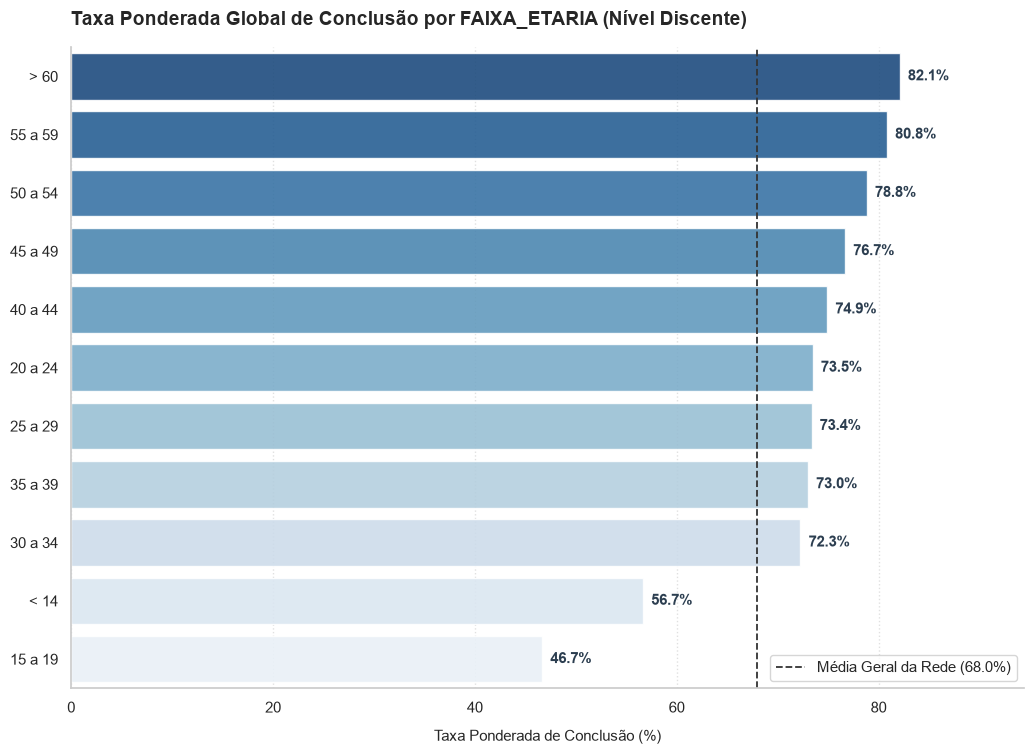

Kruskal-Wallis: H = 80.4496 | p-valor = 4.0982e-13
Comparação            Dif. Medianas (%)  Estatística U  p-valor Bruto  p-valor Ajustado   Significante?
-------------------------------------------------------------------------------------------------------
15 a 19 vs 20 a 24               -29.29         143.00           0.00              0.00  Sim (p < 0.05)
15 a 19 vs 25 a 29               -19.80         230.00           0.00              0.00  Sim (p < 0.05)
15 a 19 vs 30 a 34               -13.83         348.00           0.00              0.01  Sim (p < 0.05)
15 a 19 vs 35 a 39               -15.54         363.00           0.00              0.01  Sim (p < 0.05)
15 a 19 vs 40 a 44               -16.30         319.00           0.00              0.00  Sim (p < 0.05)
15 a 19 vs 45 a 49               -16.81         321.00           0.00              0.00  Sim (p < 0.05)
15 a 19 vs 50 a 54               -23.23         245.00           0.00              0.00  Sim (p < 0.05)
15 a 19 vs 55

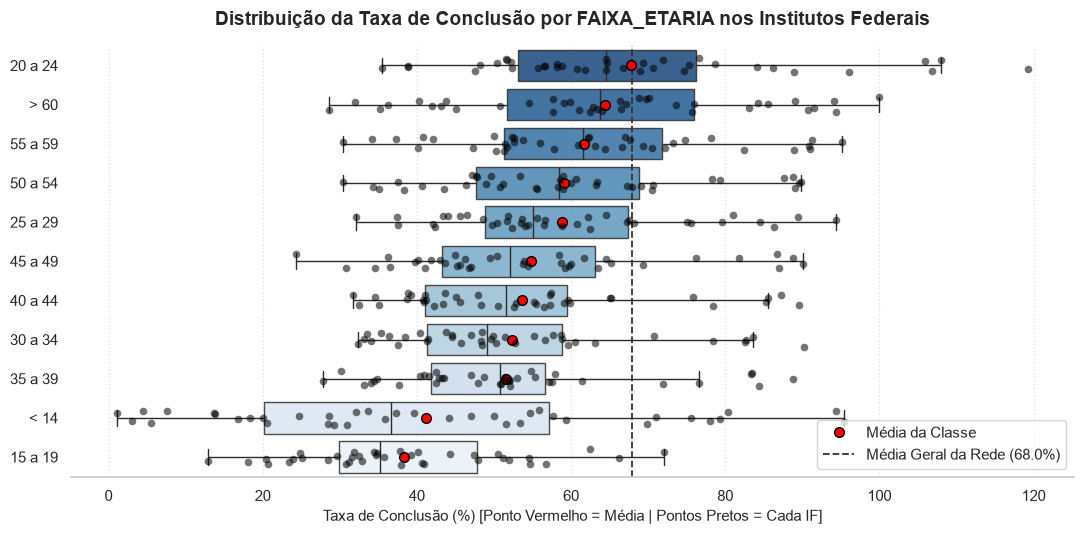



ANÁLISE ESTATÍSTICA DESCRITIVA PARA O RENDA


RENDA          N_IFS  MEDIA  DESVIO_PADRAO  MEDIANA    MIN    MAX  TAXA_PONDERADA
---------------------------------------------------------------------------------
Alta              38  54.63          17.49    51.33  27.97  88.39           75.35
Média-Alta        38  52.94          15.64    49.22  26.95  88.47           74.93
Média             38  51.66          15.16    49.31  29.35  90.28           71.81
Baixa             38  51.56          13.68    47.75  33.54  81.16           66.56
Média-Baixa       38  49.82          15.27    46.91  28.13  87.93           69.71
Muito-Baixa       38  49.18          13.71    45.65  29.39  85.19           58.42


A conclusão do aluno é DEPENDENTE de RENDA (p < 0.05).




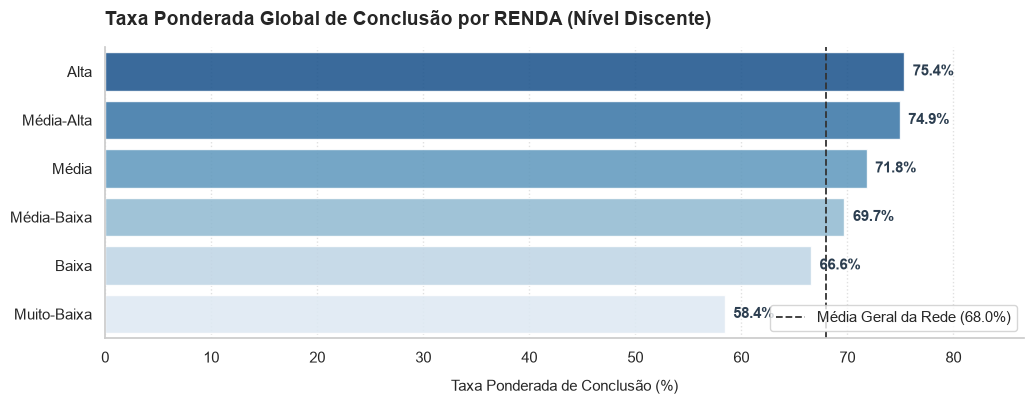

Kruskal-Wallis: H = 3.3903 | p-valor = 6.4005e-01
Não há diferença estatisticamente significante entre as medianas de RENDA.




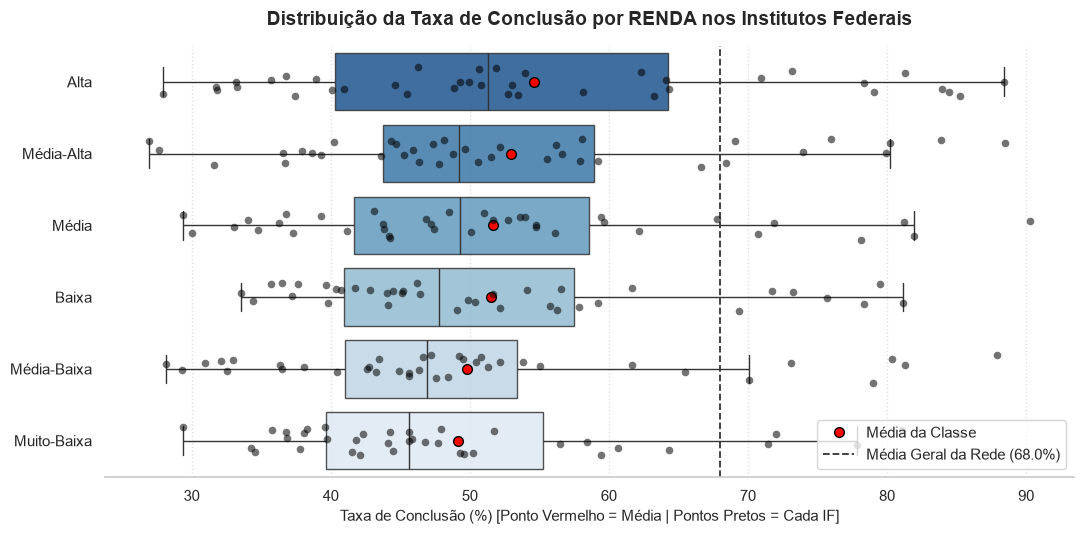



ANÁLISE ESTATÍSTICA DESCRITIVA PARA O SEXO


SEXO         N_IFS  MEDIA  DESVIO_PADRAO  MEDIANA    MIN    MAX  TAXA_PONDERADA
-------------------------------------------------------------------------------
Feminino        38  53.26          13.38    50.32  32.95  82.35           69.77
Masculino       38  48.60          13.78    43.92  28.05  82.30           65.47


A conclusão do aluno é DEPENDENTE de SEXO (p < 0.05).




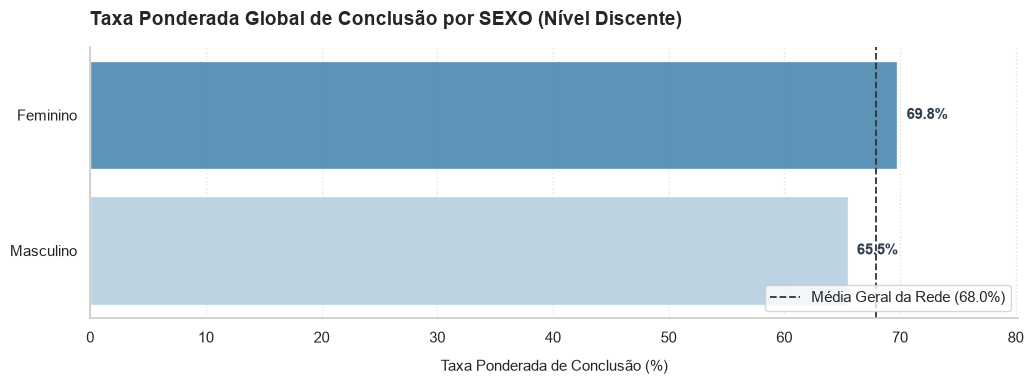

Kruskal-Wallis: H = 3.8961 | p-valor = 4.8398e-02
Comparação               Dif. Medianas (%)  Estatística U  p-valor Bruto  p-valor Ajustado   Significante?
----------------------------------------------------------------------------------------------------------
Feminino vs Masculino                 6.40         912.00           0.05              0.05  Sim (p < 0.05)




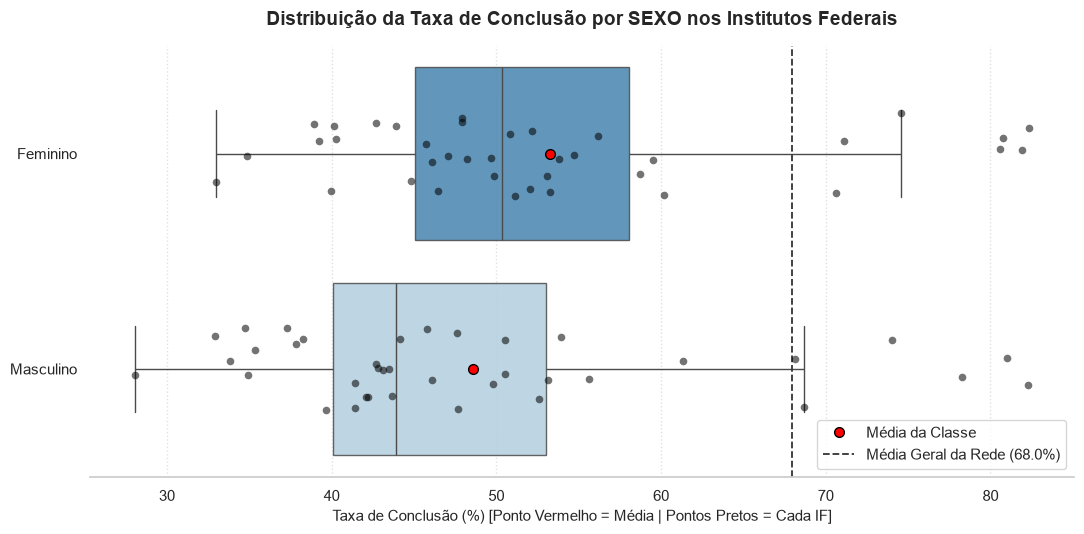

In [5]:
fatores = ['REG', 'ETNIA', 'FAIXA_ETARIA', 'RENDA', 'SEXO']

for fator in fatores:

    print("=" * 70)
    print(f"ANÁLISE ESTATÍSTICA DESCRITIVA PARA O {fator}")
    print("=" * 70)
    print("\n")

    # Preparar a base e pressupostos
    df_inst, tab_fator = prepara_dados_fator(df, fator)
    p_shapiro, p_levene = verifica_pressupostos_anova(df_inst, fator)

    # Gera tabela
    formata_tabela(tab_fator, fator)
    print("\n")

    # Teste Qui-Quadrado de Independência (Nível Discente)
    chi2, p_chi2 = executa_teste_quiquadrado(df, fator)
    if p_chi2 < 0.05:
        print(f"A conclusão do aluno é DEPENDENTE de {fator} (p < 0.05).")
    else:
        print(f"Não há associação estatisticamente significante detectada (p >= 0.05).")
    print("\n")

    # Gráfico de Barras Horizontais com a Taxa Ponderada Global (Nível Discente)
    plota_barras_ponderadas(df_inst, tab_fator, fator, fator)


    if p_shapiro > 0.05 and p_levene > 0.05:
        # Análise de Variância (ANOVA One-Way)
        f_stat, p_anova = executa_anova_oneway(df_inst, fator)
        print(f"ANOVA One-Way: F = {f_stat:.4f} | p-valor = {p_anova:.4e}")
        print("\n")
        
        if p_anova < 0.05:
            df_tukey = executa_tukey_hsd(df_inst, fator)
            formata_tabela(df_tukey, 'Comparação')
        else:
            print(f"Não há diferença estatisticamente significante entre as médias de {fator} (p >= 0.05).")
    else:
        # Teste de Kruskal-Wallis (Nível Institucional)
        h_stat, p_kruskal = executa_kruskal_wallis(df_inst, fator)
        print(f"Kruskal-Wallis: H = {h_stat:.4f} | p-valor = {p_kruskal:.4e}")

        if p_kruskal < 0.05:
            df_posthoc = executa_posthoc_mannwhitney(df_inst, fator)
            formata_tabela(df_posthoc, 'Comparação')
        else:
            print(f"Não há diferença estatisticamente significante entre as medianas de {fator}.")

    print("\n")


    # Gráfico Boxplot da distribuição dos IFs por Região
    plota_boxplot_fator(
        df=df,
        df_inst=df_inst,
        coluna_fator= fator,
        titulo_fator= fator
    )
    print("\n")
        